<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')

print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [3]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
#from cobaya_utilities import tools -- this wont import, but I don't use it at the momment anyway
import getdist
from getdist import plots, MCSamples
from getdist.mcsamples import loadMCSamples

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [1]:
# import custom helper functions and classes

import original_functions_and_classes as original_functions_and_classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import build_covariance_from_data_old
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import instrument_Pk2D

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood_A_s_version
from functions_and_classes import SO_x_DESI_Likelihood_w_emulator
from functions_and_classes import SO_x_DESI_Likelihood_sigma8_version
from functions_and_classes import Pk2DTimer

LOADING FILE: /global/u2/l/lialubit/DESIxSO/original_functions_and_classes.py
LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [4]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("data/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

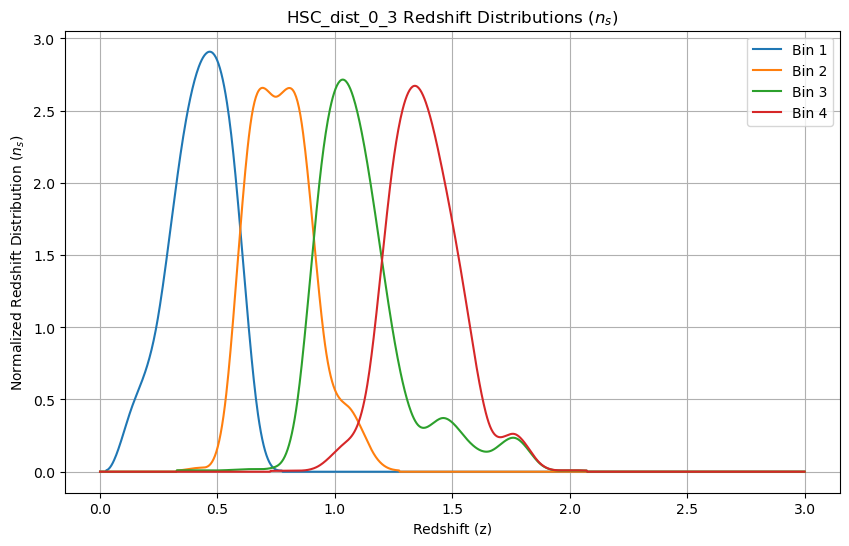

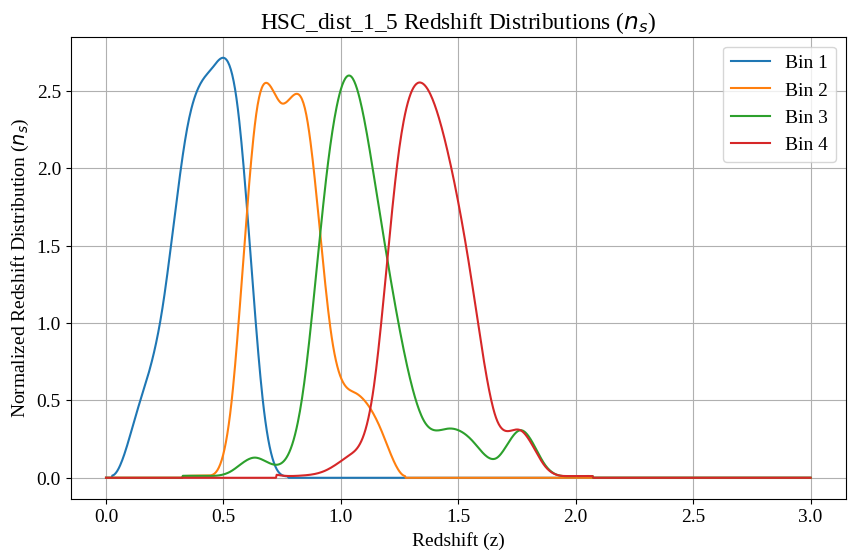

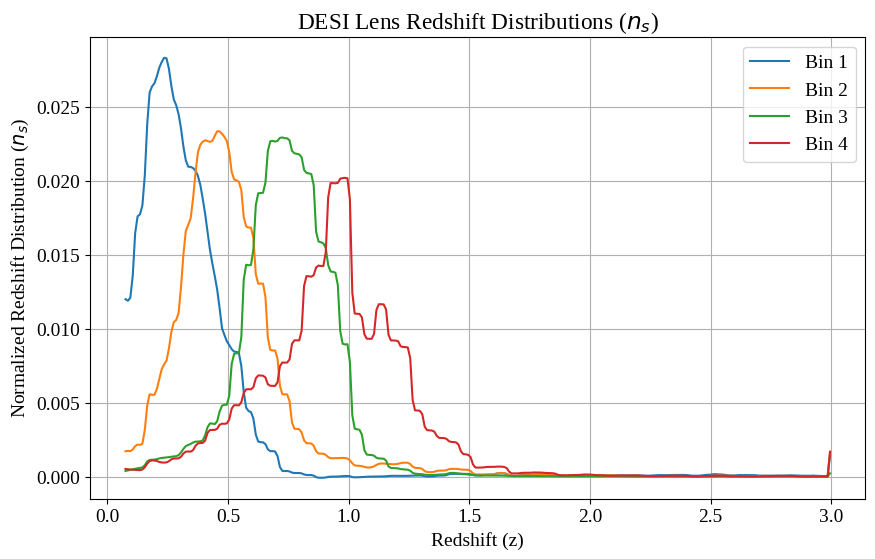

In [5]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

Mean redshifts for DESI lens bins:
  Lens Bin 1: 0.343
  Lens Bin 2: 0.522
  Lens Bin 3: 0.742
  Lens Bin 4: 0.936


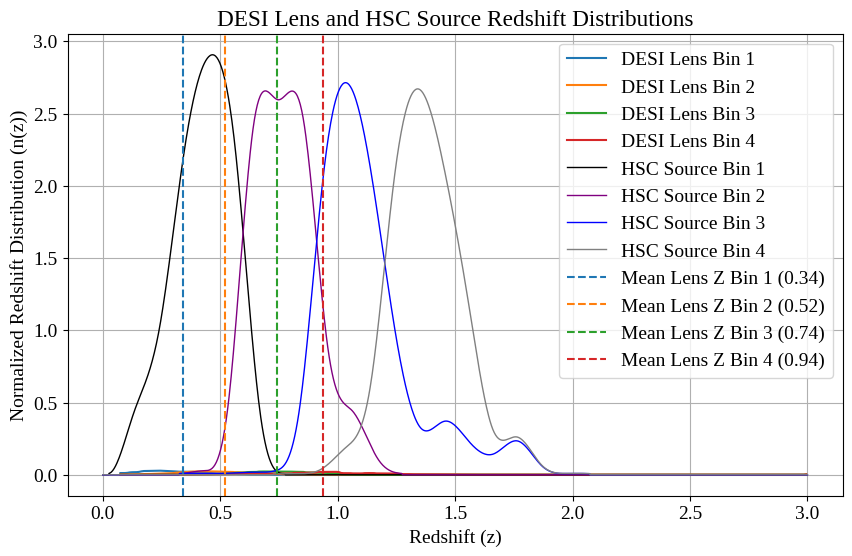

In [6]:
# calculate mean lens redshifts for each DESI lens bin
mean_desi_lens_redshifts = []

# DESI_lens_data contains z in col 0, then nz_a, nz_b, nz_c, nz_d in cols 1-4
nz_arrays_desi = [DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d]
z_lens_grid = DESI_lens_data[:, 0]

for i, n_lens_i in enumerate(nz_arrays_desi):
    if np.sum(n_lens_i) == 0:
        mean_desi_lens_redshifts.append(np.nan)
    else:
        z_l_i = scipy.integrate.trapezoid(z_lens_grid * n_lens_i, z_lens_grid) / scipy.integrate.trapezoid(n_lens_i, z_lens_grid)
        mean_desi_lens_redshifts.append(z_l_i)

print("Mean redshifts for DESI lens bins:")
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    print(f"  Lens Bin {i+1}: {z_l_i:.3f}")

# plot DESI lens distributions and the first HSC_dist_0_3 source distribution
plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='DESI Lens Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='DESI Lens Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='DESI Lens Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='DESI Lens Bin 4')

plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='HSC Source Bin 1', linestyle='-', linewidth=1, color='black')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='HSC Source Bin 2', linestyle='-', linewidth=1, color='purple')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='HSC Source Bin 3', linestyle='-', linewidth=1, color='blue')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='HSC Source Bin 4', linestyle='-', linewidth=1, color='gray')

# Add vertical lines for mean lens redshifts
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    plt.axvline(x=z_l_i, color=f'C{i}', linestyle='--', label=f'Mean Lens Z Bin {i+1} ({z_l_i:.2f})')

plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution (n(z))')
plt.title('DESI Lens and HSC Source Redshift Distributions')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [ ]:
# CCL
print('CCL cosmology parameters:')
print('Omega_c: the density fraction at z=0 of CDM.')
print('Omega_b: the density fraction at z=0 of baryons.')
print('h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.')
print('Omega_k: the curvature density fraction at 𝑧 =0.')
print('Omega_g: the density of radiation (not including massless neutrinos.')
print('w0: first order term of the dark energy equation of state.')
print('wa: second order term of the dark energy equation of state.')

In [ ]:
# CCL cosmolgoies

# сosmology -- standard CCL + DESI waw0
h = 0.6674
w0 = -0.752
wa = -0.86
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
w0wa_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, w0=w0, wa=wa, transfer_function='boltzmann_camb')

# сosmology -- standard CCL + DESI curved h and Omega_k
h = 0.6850
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
Omega_k = 2.3e-3
curved_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

# cosmology -- standard CCL + flat LCDM
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
A_s = 2.105e-9
Omega_c = 0.27
flat_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s = A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

In [ ]:
# plot angular power spectra

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['GG'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['GL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])

### CosmoPower Emulator

**CosmoPower** is a suite of neural network emulators that can predict power spectra and other parameters. In MCMC, a lot of the computation time is spent calculating power spectra for each proposed set of cosmological parameters. Cosmopower can speed this up.

We'll do some experimenting with CosmoPower and then integrate it with the MCMC.

What we need to do is:
1. Before running the MCMC, train the network on a dataset of power spectra computed using a full Boltzmann solver across a wide range of cosmological parameters, or find a pre-trained model and extrapolate from it to get the spectra we want.
2. Integrate the CosmoPower network into the Cobaya likelihood. That way, during the sampling, instead of recalculating the power spectru at each step, the pre-trained CosmoPower network will rapidly predict the power spectra. This will allow the sampler to explore much more quickly.

We'll need:
1.  **`cosmopower`**: The core library containing the trained emulators.
2.  **`cobaya-cosmopower`**: A Cobaya-specific wrapper that integrates the `cosmopower_cl` likelihood into your Cobaya runs. We'll specify a path to a pre-trained CosmoPower model (`.npz` file) for the desired power spectra (e.g., `cl_TT`, `cl_EE`, `cl_TE`, `cl_phi_phi`). This will repalce our current call to pyccl.

Notes:
1. The emulator has a k-grid but NOT a z-grid. You can dynaically set the z values and run the emulator. Our C_l's are all integrals over the line of sight (over lots of different z's) so we'll need to consider the P(k) at all the z's from here to the start of time. We'll need to figure out if that z range is suitable for all the calculations -- I need to get more into the details of the integrals of C_l's again for the different types of C_l. 
2. The standard CosmoPower uses TensorFlow which is incompatible with other packages we need. Use CosmoPower-Jax instead. (Trust me on this, don't try to make the normal CosmoPower work...)

In [ ]:
#import pre-trained P(k) emulators stored in emulator file

lin_emu = CPJ(probe='mpk_lin')
boost_emu = CPJ(probe='mpk_boost')

print('linear P(k) emulator parameters: ', lin_emu.parameters)
print('boost P(k) emulator parameters: ', boost_emu.parameters)

In [ ]:
# test new emulator functions for a simple linear power spectrum

# cosmology -- standard CCL + flat LCDM w/A_s
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
Omega_c = 0.27
A_s = 2.1 * 1e-9
n_s=0.96
flat_LCDM_cosmology2 = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

k_modes = lin_emu.modes

# PyCCL
a = 1.0 / (1.0 + 0.5)
linear_spectrum_ccl = ccl.linear_matter_power(flat_LCDM_cosmology2, k_modes, a)
non_linear_spectrum_ccl = ccl.nonlin_matter_power(flat_LCDM_cosmology2, k_modes, a)

# emulator
linear_Pk = predict_linear_Pk(flat_LCDM_cosmology2, lin_emu, 0.5)
z_grid = np.linspace(0, 10, 50)
Pk2D_full = make_Pk2D(flat_LCDM_cosmology2, linear_emulator = lin_emu, boost_emulator = boost_emu, z_arr = z_grid, cmin=3.13, eta_0=0.68)
non_linear_Pk = Pk2D_full(k=k_modes, a=a)

# plot
fig = plt.figure(figsize=(20, 10))
plt.loglog(k_modes, linear_spectrum_ccl, color='black', linewidth=5, label='Linear CCL (Boltzmann)')
plt.loglog(k_modes, non_linear_spectrum_ccl, color='purple', linewidth=5, label='Nonlinear CCL (Boltzmann)')
plt.loglog(k_modes, linear_Pk, color='blue', linewidth=5, linestyle='--', label='Linear Emulator')
plt.loglog(k_modes, non_linear_Pk, color='green', linewidth=5, linestyle=':', label=r'Nonlinear Emulator')
plt.xlabel(r'$k \quad [h \, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel(r'$P(k) \quad [h^{-3} \, \mathrm{Mpc}^3]$', fontsize=13)
plt.title(f'Matter Power Spectrum Verification at $z = {0.5}$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# scaled differences
fig = plt.figure(figsize=(20, 10))
linear_diff = (linear_Pk - linear_spectrum_ccl) / (linear_spectrum_ccl)
non_linear_diff = (non_linear_Pk - non_linear_spectrum_ccl) / (non_linear_spectrum_ccl)
plt.plot(k_modes, linear_diff, color='black', linewidth=5, label='Linear')
plt.plot(k_modes, non_linear_diff, color='purple', linewidth=5, label='Nonlinear')
plt.xlabel(r'$k \quad [h \, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel('scaled differences')
plt.title(f'Matter Power Spectrum Verification at $z = {0.5}$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

In [ ]:
# test timing and accuracy w/plots

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, # Use A_s here
    n_s=n_s, transfer_function='bbks'
)
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'])
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb'
)
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'])
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

start_time_emu_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# results
print("")
print("General Summary")
print("These times all include plotting. In my MCMC I do not actually plot the Cls, so these efficiency comparisons are a little incomplete.")
print("In a later cell I will compare just the creation.")
print("The times and differences vary each run. The final two results (see 'bottom line') generally stay between .65-1.0 and .35-.5, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lsot time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [ ]:
# test timing and accuracy w/o plots

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, n_s=n_s, transfer_function='bbks')
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no')
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb')
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
standard_Cl_CL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no')
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

#timed_Pk2D_object = instrument_Pk2D(Pk2D_full_timed)

start_time_emu_cl = time.time()
emulator_Cl_CL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no',
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# find percent of PyCCL runtime spent calling Pk2D
#timing_info = timed_Pk2D_object.get_timing_info()
#total_Pk2D_call_time_s = timing_info['total_time_ns']
#Pk2D_call_count = timing_info['call_count']
#print(f"Number of Pk2D.__call__ invocations: {Pk2D_call_count}")
#print(f"Total time spent in Pk2D.__call__ method: {total_Pk2D_call_time_s:.6f} seconds")

# separate Pk2D call
#start_time_call_Pk2D = time.time()
#temp_Pk2D = Pk2D_full_timed
#end_time_call_Pk2D = time.time()
#time_call_Pk2D = end_time_call_Pk2D - start_time_call_Pk2D
#print(f"Time to call Pk2D outside of PyCCL: {time_call_Pk2D:.4f} seconds")

# results
print("")
print("General Summary")
print("The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")
#print(f"The time to call the Pk2D object ONCE was {time_call_Pk2D / time_emu_cl} times that of the total PyCCL emulator Cl calculation (excluding emulator building).")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [ ]:
# compare the Cl's

ell_values = np.logspace(np.log10(2), np.log10(3000), 100)

# straight diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_CL.keys()):
    diff = standard_Cl_CL[key] - emulator_Cl_CL[key]
    plt.plot(ell_values, diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("Standard - Emulated")
plt.title("Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# scaled diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_CL.keys()):
    diff = standard_Cl_CL[key] - emulator_Cl_CL[key]
    scaled_diff = diff / standard_Cl_CL[key]
    plt.plot(ell_values, scaled_diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("(Standard - Emulated) / Standard")
plt.title("Scaled Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# test timing and accuracy w/o plots -- LL

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, n_s=n_s, transfer_function='bbks')
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no')
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb')
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
standard_Cl_LL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no')
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

#timed_Pk2D_object = instrument_Pk2D(Pk2D_full_timed)

start_time_emu_cl = time.time()
emulator_Cl_LL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no',
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# find percent of PyCCL runtime spent calling Pk2D
#timing_info = timed_Pk2D_object.get_timing_info()
#total_Pk2D_call_time_s = timing_info['total_time_ns']
#Pk2D_call_count = timing_info['call_count']
#print(f"Number of Pk2D.__call__ invocations: {Pk2D_call_count}")
#print(f"Total time spent in Pk2D.__call__ method: {total_Pk2D_call_time_s:.6f} seconds")

# separate Pk2D call
#start_time_call_Pk2D = time.time()
#temp_Pk2D = Pk2D_full_timed
#end_time_call_Pk2D = time.time()
#time_call_Pk2D = end_time_call_Pk2D - start_time_call_Pk2D
#print(f"Time to call Pk2D outside of PyCCL: {time_call_Pk2D:.4f} seconds")

# results
print("")
print("General Summary")
print("The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")
#print(f"The time to call the Pk2D object ONCE was {time_call_Pk2D / time_emu_cl} times that of the total PyCCL emulator Cl calculation (excluding emulator building).")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [ ]:
# compare the Cl LL's

ell_values = np.logspace(np.log10(2), np.log10(3000), 100)

# straight diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_LL.keys()):
    diff = standard_Cl_LL[key] - emulator_Cl_LL[key]
    plt.plot(ell_values, diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("Standard - Emulated")
plt.title("Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# scaled diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_LL.keys()):
    diff = standard_Cl_LL[key] - emulator_Cl_LL[key]
    scaled_diff = diff / standard_Cl_LL[key]
    plt.plot(ell_values, scaled_diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("(Standard - Emulated) / Standard")
plt.title("Scaled Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\phi\phi}, C_\ell^{gg}, C_\ell^{\gamma\gamma}, C_\ell^{g\gamma}, C_\ell^{g\phi}, C_\ell^{\gamma\phi}]$$

Note: $\phi$ should really read $\kappa$ but this was built with $\phi$ and changing it has spawned a bunch of errors and mismatches so I'm sticking with $\phi$

This vector consists of:
* **CMB lensing convergence power spectrum:** $C_\ell^{\phi\phi}$
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)
* **Galaxy lensing auto/cross-spectrum:** $C_\ell^{\gamma\gamma}$ (cosmic shear)
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\gamma}$ (galaxy-galaxy lensing)
* **Lens galaxies–CMB lensing cross-spectrum:** $C_\ell^{g\phi}$
* **Galaxy lensing–CMB lensing cross-spectrum:** $C_\ell^{\gamma\phi}$

If we have **a** lens bins and **b** source bins we have 1 CMB, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-CMB, and b source-CMB spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [7]:
# build DESI, SO noise, and magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# shape noise ref: slack from Simone, can't find the Github itself
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
DESI_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree

# Convert n_bar from per deg^2 to per steradian
# 1 steradian = (180/pi)^2 square degrees
DESI_n_bar_steradian = DESI_n_bar_deg2 * (180.0 / np.pi)**2

DESI_shot_noise = np.zeros_like(DESI_n_bar_steradian)
DESI_shape_noise = np.zeros_like(DESI_n_bar_steradian)
for i in range(len(DESI_shot_noise)):
    DESI_shot_noise[i] = 1 / DESI_n_bar_steradian[i]
    DESI_shape_noise[i] = sigma ** 2 / DESI_n_bar_steradian[i]

# CMB noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_kk = SO_noise_data[:, 7]
ells_for_noise_interp = np.arange(2, 3000 + 2) # Assuming n_ell = 3000 as used in examples -- this is meant to be the same as the ells for our Cl_s

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_kk_func = interp1d(S_noise_ells, N_kk, bounds_error=False, fill_value=(N_kk[0], N_kk[-1]))
SO_CMB_noise = interpolated_N_kk_func(ells_for_noise_interp)
# Handle potential negative noise if for some reason the source data contains them, set to a small positive number
SO_CMB_noise[SO_CMB_noise < 0] = 1e-30 # Or whatever appropriate small value

# save
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/SO_CMB_noise.npy", SO_CMB_noise)
print("Saved SO_CMB_noise to data/SO_CMB_noise.npy")

Saved SO_CMB_noise to data/SO_CMB_noise.npy


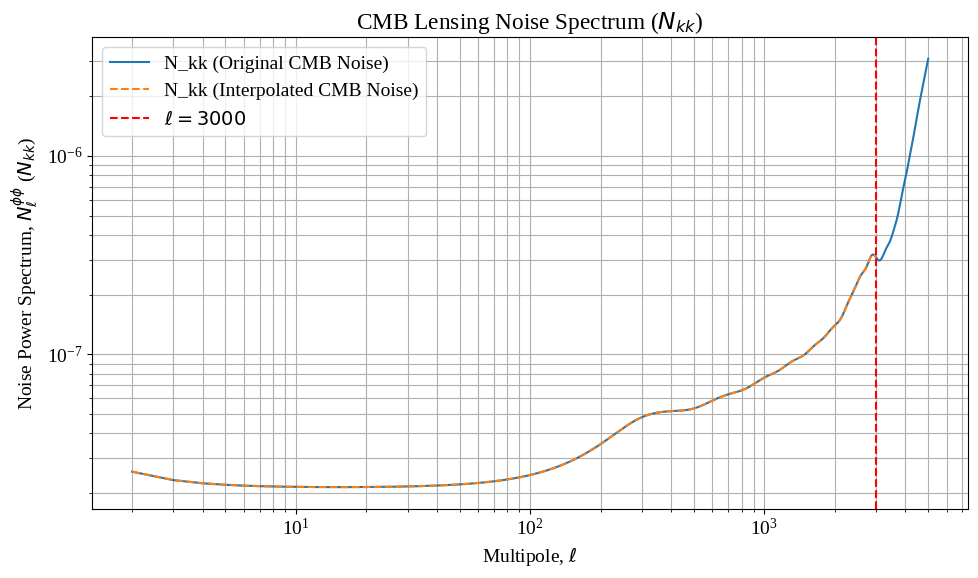

In [8]:
# plot N_kk to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(S_noise_ells, N_kk, label='N_kk (Original CMB Noise)')
plt.loglog(ells_for_noise_interp, SO_CMB_noise, label='N_kk (Interpolated CMB Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}^{\phi\phi}$ ($N_{kk}$)')
plt.title('CMB Lensing Noise Spectrum ($N_{kk}$)')
plt.axvline(x=3000, color='red', linestyle='--', label='$\ell = 3000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [ ]:
# example without noise

# build the matrix!
CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map = build_covariance_from_data(flat_LCDM_cosmology, DESI_lens_data, HSC_dist_0_3, f_sky=0.4, n_ell=3000, binsize=50, desired_spectra=['CG', 'GL'], magnification_bias_lenses = 0.8, linear_emulator = None, boost_emulator = None)

# plot the noiseless spectra
# Get the desired pairs for CG and GL
cg_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])
gl_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])

#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noiseless Angular Power Spectrum', desired_spectra=cg_pairs)
#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noiseless Angular Power Spectrum', desired_spectra=gl_pairs)

# Pass binsize to plotting functions as well
plot_covariance_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])
noiseless_corr_matrix = plot_correlation_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])

#non_zero = noiseless_corr_matrix[noiseless_corr_matrix != 0]
#min_val = np.min(non_zero)
#print("The lowest non-zero correlation is: ", min_val)

In [ ]:
# example without noise AND WITH EMULATOR

# build the matrix!
CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map = build_covariance_from_data(flat_LCDM_cosmology, DESI_lens_data, HSC_dist_0_3, f_sky=0.4, n_ell=3000, binsize=50, desired_spectra=['CG', 'GL'], magnification_bias_lenses = 0.8, linear_emulator=lin_emu, boost_emulator=boost_emu)

# plot the noiseless spectra
# Get the desired pairs for CG and GL
cg_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])
gl_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])

#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noiseless Angular Power Spectrum', desired_spectra=cg_pairs, linear_emulator=lin_emu, boost_emulator=boost_emu)
#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noiseless Angular Power Spectrum', desired_spectra=gl_pairs, linear_emulator=lin_emu, boost_emulator=boost_emu)

# Pass binsize to plotting functions as well
plot_covariance_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])
noiseless_corr_matrix = plot_correlation_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])

#non_zero = noiseless_corr_matrix[noiseless_corr_matrix != 0]
#min_val = np.min(non_zero)
#print("The lowest non-zero correlation is: ", min_val)

In [ ]:
# example with noise

t0 = time.time()

# build the matrix!
CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map = build_covariance_from_data(flat_LCDM_cosmology, DESI_lens_data, HSC_dist_0_3, f_sky=0.4, n_ell=3000, binsize=50, desired_spectra=['CG', 'GL'], shot_noise_lens = DESI_shot_noise, shape_noise_source = DESI_shape_noise, cmb_noise_phi = SO_CMB_noise, magnification_bias_lenses = 0.8, linear_emulator = None, boost_emulator = None)

# plot the noisy spectra
# Get the desired pairs for CG and GL
cg_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])
gl_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])

#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noisy Angular Power Spectrum', desired_spectra=cg_pairs)
#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noisy Angular Power Spectrum', desired_spectra=gl_pairs)

# Pass binsize to plotting functions as well
plot_covariance_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])
noisy_corr_matrix = plot_correlation_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])

tf = time.time()

print("computation time: ", tf - t0)
# what is the lowest non-zero value in the noisy matrix? -- that is, what are those tiny non-zero correlations we see?
#non_zero = noisy_corr_matrix[noisy_corr_matrix != 0]
#min_val = np.min(non_zero)
#print("The lowest non-zero correlation is: ", min_val)

In [ ]:
# example with noise AND WITH EMULATOR

t0 = time.time() 

# build the matrix!
CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map = build_covariance_from_data(flat_LCDM_cosmology, DESI_lens_data, HSC_dist_0_3, f_sky=0.4, n_ell=3000, binsize=50, desired_spectra=['CG', 'GL'], shot_noise_lens = DESI_shot_noise, shape_noise_source = DESI_shape_noise, cmb_noise_phi = SO_CMB_noise, magnification_bias_lenses = 0.8, linear_emulator=lin_emu, boost_emulator=boost_emu)

# plot the noisy spectra
# Get the desired pairs for CG and GL
cg_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])
gl_pairs = create_simplified_desired_pairs(DESI_lens_data.shape[1]-1, HSC_dist_0_3.shape[1]-1, ['CC', 'LL', 'GG'])

#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noisy Angular Power Spectrum', desired_spectra=cg_pairs, linear_emulator=lin_emu, boost_emulator=boost_emu)
#plot_spectra_from_dict(CG_GL_spectra_dict, title_prefix='Noisy Angular Power Spectrum', desired_spectra=gl_pairs, linear_emulator=lin_emu, boost_emulator=boost_emu)

# Pass binsize to plotting functions as well
plot_covariance_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])
noisy_corr_matrix = plot_correlation_matrix(CG_GL_cov, CG_GL_spectra_dict, CG_GL_f_map, binsize=50, desired_spectra=['CG', 'GL'])


tf = time.time()

print("computation time: ", tf - t0)

# what is the lowest non-zero value in the noisy matrix? -- that is, what are those tiny non-zero correlations we see?
#non_zero = noisy_corr_matrix[noisy_corr_matrix != 0]
#min_val = np.min(non_zero)
#print("The lowest non-zero correlation is: ", min_val)

In [ ]:
# NOTHING BELOW HERE HAS BEEN MODIFIED TO WORK WITH THE EMULATOR OR THE MODIFIED FUNCTIONS

## Cobaya

1.  **Parameters**: The cosmological parameters we want to constrain (e.g., $\Omega_m$, $\sigma_8$, $h$).
2.  **Likelihood**: A Python class that calculates the log-likelihood $L(\mathbf{D}|\mathbf{\theta})$, where $\mathbf{D}$ is the data vector and $\mathbf{\theta}$ are the cosmological parameters. For a Gaussian likelihood, this involves comparing a theoretical model (based on $\mathbf{\theta}$) to an observed data vector (which we'll treat as a fiducial model with noise) and using a covariance matrix.
3.  **Prior**: The prior distributions for our parameters.
4.  **Sampler**: The MCMC algorithm Cobaya will use to explore the parameter space.

### Likelihood

$$\ln L = -\frac{1}{2} (\mathbf{D} - \mathbf{M}(\mathbf{\theta}))^T \mathbf{C}^{-1} (\mathbf{D} - \mathbf{M}(\mathbf{\theta})) - \frac{1}{2} \ln |\mathbf{C}|$$

where:
*   $\mathbf{D}$ is the 'observed' data vector (derived from a fiducial cosmology with noise).
*   $\mathbf{M}(\mathbf{\theta})$ is the model prediction for the data vector, calculated using the given cosmological parameters $\mathbf{\theta}$.
*   $\mathbf{C}$ is the covariance matrix.

We already have the infrastructure to build the covariance matrix and calculate the theoretical $C_\ell$ values for a given cosmology. Now, we need to wrap this logic into a Cobaya-compatible likelihood class.

### Parameters and Sampler

**Parameters (params section):**

*   **prior**: The prior distribution for the parameter (e.g., min/max for a flat prior, loc/scale for a Gaussian).
*   **ref**: A reference value, often used by samplers to initiate chains or define a starting point.
*   **proposal**: The width of the proposal distribution for the sampler (how much the parameter changes in each step).
*   **latex**: A LaTeX representation for plotting and reporting.

**Sampler (sampler section):**

*   **Rminus1_stop**: A convergence criterion (Gelman-Rubin statistic minus 1). Smaller values indicate better convergence.
*   **max_samples**: The maximum number of samples to generate.



In [9]:
# make and save noise and data files for just the first bin

# make sure folder exists
os.makedirs("data", exist_ok=True)

# data
DESI_lens_data_bin1 = DESI_lens_data[:, :2]  # z + first lens bin
HSC_dist_0_3_bin1 = HSC_dist_0_3[:, :2]       # z + first source bin

# noise
DESI_shot_noise_bin1 = np.array([DESI_shot_noise[0]])
DESI_shape_noise_bin1 = np.array([DESI_shape_noise[0]])
#SO_CMB_noise was already saved

# save
np.save("data/DESI_lens_data_bin1.npy", DESI_lens_data_bin1)
np.save("data/HSC_dist_0_3_bin1.npy", HSC_dist_0_3_bin1)
np.save("data/DESI_shot_noise_bin1.npy", DESI_shot_noise_bin1)
np.save("data/DESI_shape_noise_bin1.npy", DESI_shape_noise_bin1)
#SO_CMB_noise was already saved
    
# check
print("DESI_lens_data_bin1 shape:", DESI_lens_data_bin1.shape)
print("HSC_dist_0_3_bin1 shape:", HSC_dist_0_3_bin1.shape)
print("DESI_shot_noise_bin1:", DESI_shot_noise_bin1)
print("DESI_shape_noise_bin1:", DESI_shape_noise_bin1)
print("SO_CMB_noise:", SO_CMB_noise)

DESI_lens_data_bin1 shape: (293, 2)
HSC_dist_0_3_bin1 shape: (1000, 2)
DESI_shot_noise_bin1: [3.71938241e-06]
DESI_shape_noise_bin1: [2.51430251e-07]
SO_CMB_noise: [2.566829e-08 2.327497e-08 2.244052e-08 ... 3.078634e-07 3.076747e-07
 3.074863e-07]


In [34]:
# For the sake of future errors, I'm saving this copy with a summary of my various debugging efforts. I have changed the order a bit, but the general strucutre should be clear, and the useful cells remain.

In [ ]:
# Summary of The MCMC Problem, My Debugging Efforts, and My Conclusions (June 3 to June 5)

# The Original Problem: my MCMC, when run with my new functions_and_classes files and likelihoods, consistently pushed omega_m to unphysically high values

# Initial MCMC Tests:
# 1. ran the MCMC with the new likelihood and A_s with and without the emulator, and on and off a NERSC exlusive node (login node only non-emulator): none worked, so I concluded that the issue probably was not primarily with the emulator or the node
# 2. ran the MCMC without the emulator with the new likelihood with A_s and sigma8 cosmologies: both failed, so I figured that the issue was probably in the likelihood, the functions it called, or the matrix/vector 
# 3. ran the MCMC with the old likelihood and the with the new functions_and_flasses and the new and old matrix/data vector: both failed, so I concluded that there was something broken in my new functions_and_classes_file
# 4. ran the original likelihood with the original matrix/vector and the original functions: this worked once and failed once

# Fix 1: I decreased the proposal step 

# More MCMC Tests: 
# 1. ran the original likelihood with the original matrix/vector and the original functions and a smaller proposal: this worked
# 2. ran the likelihood w original covariance and data and new functions and smaller proposal step: this failed, so I concluded something was wrong with the new functions_and_classes file, namely with the things being called by the original likelihood, that something might be wrong with the new matrix and vector functions, and that something may or may not be wrong with the new likelihoods and .yaml files

# Functions and Classes Tests:
# 1. built f_maps, tracer_dicts, and spectra_dicts using old and new functions_and_classes: these we identical
# 2. built covariance matrices using old and new CovarianceMatrix classes: these were also identical
# 3. built covariance matrices using old and new build_covariance_matrix functions: these were NOT identical so I concluded that something was breaking within the functions_and_classes files, though I raelly had no idea what it was
# 4. compared the matrices and the files line by line (there's a good little bit of code that you can put into the terminal to compare): figured out that everything was identical but the parts involving cmb lensing
#    -- realized that the issue was that I had switched from phi to kappa in the new functions_and_classes since that was technically a more correct label

# Fix 2: I changed all the kappa's back to phi's (this is not ideal labeling, but it fixes the issue and I'll change it again another time)

# More MCMC Tests
# 1. ran old likelihoods with old matrix/vector and new functions_and_classes: this worked
# 2. ran new likelihoods with old matrix/vector and new functions_and_classes: this failed, so I figured something was wrong with my likelihood

# Fix 3: constrained the reference (don't love how strict it is now)

# More MCMC Tests
# 1. ran old likelihoods with new matrix/vector and new functions_and_classes: this failed, so I concluded that something was still wrong with the covariance matrix and the data vector

# Covariance Matrix Tests
# 1. compared new sigma8 and old matrix/vector: these were different
# 2. compared new sigma8 matrix/vector with matrix/vector calculated entirely with old functions_and_classes: these were the same...
# 2. compared old matrix/vector with matrix/vector calculated entirely with old functions and classes: these were different!!
#    -- this really baffled me, cause for all intents and purposes these should have been identical
#    -- "lowkey what the hell"
#    -- concluded there was some global parameter shift or other hidden process making the calculations of matrices different than they used to be
#    -- "It's honestly a really interesting puzzle, and I think I'd be rather enjoy myself if not for the sense of time pressure. Anyway it looks like there's something messing us up, but only in one of the data vector bins... The plot thickens."
# 3. compared specific blocks of old matrix/vector and matrix/vector calcualted with old_functions_and_classes: found that the differences lay generally in blocks related to CC
# 4. plotted various different CC's 
#    -- realized that the problem was that in the original Cobaya run a month ago, SO_CMB_noise had been suppressed (the most recent call had decreased it by a huge factor in order to test the noisy covariance matrix function)
# 5. reran new functions with no CMB noise: these were basically identical, so I concluded that the noise was the issue
#    -- I now understand why the matrices are different, but I don't know why the matrix/vector with noise causes the MCMC to fail

# Fix 3.5: get rid of CMB noise -- this is not sustainable

# The Next Task: figure out how to properly incorporate the SO noise (I think this might have to do with binning, and at which point different values are binned)

In [ ]:
# compare old and new functions and outputs

In [27]:
import importlib
import numpy as np
import functions_and_classes as new_version
importlib.reload(new_version)
import original_functions_and_classes as old_version
importlib.reload(old_version)

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
A_s = 2.105e-9
Omega_c = 0.27
sigma8 = 0.8
fiducial_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8 = sigma8,
                               n_s=n_s, transfer_function='boltzmann_camb')

linear_emulator = None
boost_emulator = None

old_lens_tracers, old_source_tracers, old_cmb_tracer = old_version.build_tracers_from_data(
    fiducial_cosmology, 
    DESI_lens_data_bin1, 
    HSC_dist_0_3_bin1, 
    magnification_bias_lenses=0.8)
new_lens_tracers, new_source_tracers, new_cmb_tracer = new_version.build_tracers_from_data(
    fiducial_cosmology, 
    DESI_lens_data_bin1, 
    HSC_dist_0_3_bin1, 
    magnification_bias_lenses=0.8)

old_tracer_dict = old_version.build_tracer_dict(old_lens_tracers, old_source_tracers, old_cmb_tracer)
new_tracer_dict = new_version.build_tracer_dict(new_lens_tracers, new_source_tracers, new_cmb_tracer)

n_lens_bins = 1
n_src_bins = 1
n_ell = 3000
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']
desired_pairs_list_old = old_version.create_simplified_desired_pairs(
    n_lens_bins=n_lens_bins, 
    n_source_bins=n_src_bins, 
    desired_spectra=desired_spectra
)
desired_pairs_list_new = new_version.create_simplified_desired_pairs(
    n_lens_bins=n_lens_bins, 
    n_source_bins=n_src_bins, 
    desired_spectra=desired_spectra
)

f_map_old = old_version.ForecastMap(
    n_lens=DESI_lens_data_bin1.shape[1] - 1, 
    n_src=HSC_dist_0_3_bin1.shape[1] - 1, 
    n_ell=n_ell, 
    desired_pairs=desired_pairs_list_old
)
f_map_new = new_version.ForecastMap(
    n_lens=DESI_lens_data_bin1.shape[1] - 1, 
    n_src=HSC_dist_0_3_bin1.shape[1] - 1, 
    n_ell=n_ell, 
    desired_pairs=desired_pairs_list_new
)

ells_for_noise_interp = np.arange(2, 3000 + 2)
noise_dict_old = old_version.build_noise_dict(
    f_map=f_map_old,
    ells=ells_for_noise_interp,
    shot_noise_lens=DESI_shot_noise_bin1,
    shape_noise_source=DESI_shape_noise_bin1,
    cmb_noise_phi=SO_CMB_noise
)
noise_dict_new = new_version.build_noise_dict(
    f_map=f_map_old,
    ells=ells_for_noise_interp,
    shot_noise_lens=DESI_shot_noise_bin1,
    shape_noise_source=DESI_shape_noise_bin1,
    cmb_noise_phi=SO_CMB_noise
)

spectra_dict_old = old_version.build_spectra_dict(
    cosmo=fiducial_cosmology,
    f_map=f_map_old,
    tracer_dict=old_tracer_dict,
    ells=ells_for_noise_interp,
    noise_dict=noise_dict_old
)
spectra_dict_new = new_version.build_spectra_dict(
    cosmo=fiducial_cosmology,
    f_map=f_map_new,
    tracer_dict=new_tracer_dict,
    ells=ells_for_noise_interp,
    noise_dict=noise_dict_new, 
    linear_emulator = linear_emulator,
    boost_emulator = boost_emulator
)

print(spectra_dict_old)
print(spectra_dict_new)

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py
LOADING FILE: /global/u2/l/lialubit/DESIxSO/original_functions_and_classes.py
{('phi', 'phi'): array([8.87416918e-08, 1.04331952e-07, 1.17972911e-07, ...,
       3.09626555e-07, 3.09436910e-07, 3.09247567e-07], shape=(3000,)), ('g1', 'phi'): array([8.03820001e-07, 1.00181437e-06, 1.13954621e-06, ...,
       2.81651792e-09, 2.81493467e-09, 2.81335568e-09], shape=(3000,)), ('l1', 'phi'): array([1.77565503e-08, 2.24335704e-08, 2.45796239e-08, ...,
       3.73109660e-11, 3.72889497e-11, 3.72669519e-11], shape=(3000,)), ('g1', 'g1'): array([2.62225624e-05, 3.10460369e-05, 3.42990472e-05, ...,
       3.77129078e-06, 3.77125945e-06, 3.77122812e-06], shape=(3000,)), ('g1', 'l1'): array([3.40322430e-07, 4.62365502e-07, 5.33432758e-07, ...,
       7.90518594e-10, 7.90030455e-10, 7.89543798e-10], shape=(3000,)), ('l1', 'l1'): array([2.61342969e-07, 2.64775159e-07, 2.66024987e-07, ...,
       2.51443485e-07, 2.51443477e-07, 2.514

In [29]:
# 1. Check if the list of pairs matches perfectly
if f_map_old.pairs == f_map_new.pairs:
    print("✅ Success! Both ForecastMap objects have identical pairs and identical ordering.")
else:
    print("❌ Pair mismatch found!")
    print(f"Old pairs ({len(f_map_old.pairs)}): {f_map_old.pairs}")
    print(f"New pairs ({len(f_map_new.pairs)}): {f_map_new.pairs}")
    
    # Check if they have the same pairs but just in a different order
    if set(f_map_old.pairs) == set(f_map_new.pairs):
        print("⚠️ Note: The pairs are identical, but their ORDER is different!")

✅ Success! Both ForecastMap objects have identical pairs and identical ordering.


In [20]:
cov_old = old_version.CovarianceMatrix(f_map_old, spectra_dict_old, f_sky, binsize=50)
cov_old = cov_old.matrix
cov_new = new_version.CovarianceMatrix(f_map_new, spectra_dict_new, f_sky, binsize=50)
cov_new = cov_new.matrix

# 1. Total shape check
#print(f"Old Covariance Shape: {cov_old.shape}")
#print(f"New Covariance Shape: {cov_new.shape}")

# 2. Strict absolute equality check
if np.array_equal(cov_old, cov_new):
    print("\n✅ Success! Both covariance matrices are exactly identical down to machine precision.")
else:
    print("\n❌ Matrices differ numerically.")
    
# 3. Quantify the absolute difference
max_abs_diff = np.max(np.abs(cov_old - cov_new))
mean_abs_diff = np.mean(np.abs(cov_old - cov_new))
print(f"-> Max Absolute Discrepancy: {max_abs_diff:.6e}")
print(f"-> Mean Absolute Discrepancy: {mean_abs_diff:.6e}")
    
# 4. Quantify fractional/relative differences safely (avoiding divide-by-zero)
denom = np.where(cov_old == 0, 1e-15, cov_old)
max_frac_diff = np.max(np.abs(cov_old - cov_new) / np.abs(denom)) * 100
print(f"-> Max Fractional Discrepancy: {max_frac_diff:.4f}%")


✅ Success! Both covariance matrices are exactly identical down to machine precision.
-> Max Absolute Discrepancy: 0.000000e+00
-> Mean Absolute Discrepancy: 0.000000e+00
-> Max Fractional Discrepancy: 0.0000%


In [21]:
# 1. Quantify the difference
max_diff = np.max(np.abs(cov_old - cov_new))
print(f"Max absolute discrepancy: {max_diff:.6e}")

# 2. Locate the indices where they disagree
diff_indices = np.where(cov_old != cov_new)

if len(diff_indices[0]) > 0:
    first_row = diff_indices[0][0]
    first_col = diff_indices[1][0]
    
    print(f"\nFirst numerical difference found at Matrix Index: [{first_row}, {first_col}]")
    print(f"-> cov_old value: {cov_old[first_row, first_col]:.6e}")
    print(f"-> cov_new value: {cov_new[first_row, first_col]:.6e}")
    
    # 3. Map the index back to the specific pair blocks
    # Since your binsize is 50, each block is exactly 60 elements wide (3000 / 50)
    block_row_idx = first_row // 60
    block_col_idx = first_col // 60
    
    pair_row = f_map_old.pairs[block_row_idx]
    pair_col = f_map_old.pairs[block_col_idx]
    
    print(f"-> This index belongs to the covariance block between: '{pair_row}' and '{pair_col}'")
else:
    print("\nWait, are they actually identical here?")

Max absolute discrepancy: 0.000000e+00

Wait, are they actually identical here?


In [22]:
import numpy as np

# 1. Load the saved matrices directly from your disk
cov_old = np.load("cobaya_data/original_single_bin_covariance_matrix.npy")
cov_new = np.load("cobaya_data/single_bin_covariance_matrix_sigma8.npy")

print(f"Old Covariance Shape: {cov_old.shape}")
print(f"New Covariance Shape: {cov_new.shape}")

if np.array_equal(cov_old, cov_new):
    print("\n✅ Success! Both covariance matrices are exactly identical down to machine precision.")
else:
    print("\n❌ Matrices differ numerically.")

# 2. Check if the numerical values match exactly
max_abs_diff = np.max(np.abs(cov_old - cov_new))

# Calculate max fractional difference where the old covariance is non-zero
denom = np.where(cov_old == 0, 1e-15, cov_old)
max_frac_diff = np.max(np.abs(cov_old - cov_new) / np.abs(denom)) * 100

print("\n--- Saved Matrix Comparison ---")
print(f"Max Absolute Discrepancy: {max_abs_diff:.6e}")
print(f"Max Fractional Discrepancy: {max_frac_diff:.4f}%")

Old Covariance Shape: (360, 360)
New Covariance Shape: (360, 360)

❌ Matrices differ numerically.

--- Saved Matrix Comparison ---
Max Absolute Discrepancy: 5.133600e-14
Max Fractional Discrepancy: 3409254.4366%


In [23]:
import numpy as np

# 1. Quantify the difference
max_diff = np.max(np.abs(cov_old - cov_new))
print(f"Max absolute discrepancy: {max_diff:.6e}")

# 2. Locate the indices where they disagree
diff_indices = np.where(cov_old != cov_new)

if len(diff_indices[0]) > 0:
    first_row = diff_indices[0][0]
    first_col = diff_indices[1][0]
    
    print(f"\nFirst numerical difference found at Matrix Index: [{first_row}, {first_col}]")
    print(f"-> cov_old value: {cov_old[first_row, first_col]:.6e}")
    print(f"-> cov_new value: {cov_new[first_row, first_col]:.6e}")
    
    # 3. Map the index back to the specific pair blocks
    # Since your binsize is 50, each block is exactly 60 elements wide (3000 / 50)
    block_row_idx = first_row // 60
    block_col_idx = first_col // 60
    
    pair_row = f_map_old.pairs[block_row_idx]
    pair_col = f_map_old.pairs[block_col_idx]
    
    print(f"-> This index belongs to the covariance block between: '{pair_row}' and '{pair_col}'")
else:
    print("\nWait, are they actually identical here?")

Max absolute discrepancy: 5.133600e-14

First numerical difference found at Matrix Index: [120, 120]
-> cov_old value: 3.811321e-13
-> cov_new value: 4.324681e-13
-> This index belongs to the covariance block between: '('g1', 'phi')' and '('g1', 'phi')'


In [24]:
import numpy as np

# Load the data vectors
vec_orig = np.load('cobaya_data/original_single_bin_data_vector.npy')
vec_sigma8 = np.load('cobaya_data/single_bin_data_vector_sigma8.npy')

# Each spectrum block has a fixed size (n_ell / binsize)
# Let's dynamically find how many blocks are in each file
block_size = int(np.ceil(3000 / 50)) # 60 elements per block
num_blocks_orig = len(vec_orig) // block_size
num_blocks_sigma8 = len(vec_sigma8) // block_size

print(f"Original Vector: {len(vec_orig)} elements ({num_blocks_orig} blocks)")
print(f"Sigma8 Vector:   {len(vec_sigma8)} elements ({num_blocks_sigma8} blocks)\n")

print("--- Block Mean Values Comparison ---")
for i in range(max(num_blocks_orig, num_blocks_sigma8)):
    orig_mean = np.mean(vec_orig[i*block_size:(i+1)*block_size]) if i < num_blocks_orig else "N/A"
    sigma8_mean = np.mean(vec_sigma8[i*block_size:(i+1)*block_size]) if i < num_blocks_sigma8 else "N/A"
    
    print(f"Block {i}:  Original Mean = {orig_mean}  |  Sigma8 Mean = {sigma8_mean}")

Original Vector: 360 elements (6 blocks)
Sigma8 Vector:   360 elements (6 blocks)

--- Block Mean Values Comparison ---
Block 0:  Original Mean = 4.5116300499713556e-06  |  Sigma8 Mean = 4.5116300499713556e-06
Block 1:  Original Mean = 1.2876100131719984e-08  |  Sigma8 Mean = 1.2876100131719984e-08
Block 2:  Original Mean = 3.74414619390176e-08  |  Sigma8 Mean = 3.74414619390176e-08
Block 3:  Original Mean = 2.516887034268387e-07  |  Sigma8 Mean = 2.516887034268387e-07
Block 4:  Original Mean = 5.779214257750961e-10  |  Sigma8 Mean = 5.779214257750961e-10
Block 5:  Original Mean = 1.9881025575430055e-08  |  Sigma8 Mean = 1.4907394118016756e-07


In [26]:
import numpy as np

# 1. Quantify the difference
max_diff = np.max(np.abs(cov_old - cov_new))
print(f"Max absolute discrepancy: {max_diff:.6e}")

# 2. Locate the indices where they disagree
diff_indices = np.where(cov_old != cov_new)

if len(diff_indices[0]) > 0:
    first_row = diff_indices[0][0]
    first_col = diff_indices[1][0]
    
    print(f"\nFirst numerical difference found at Matrix Index: [{first_row}, {first_col}]")
    print(f"-> cov_old value: {cov_old[first_row, first_col]:.6e}")
    print(f"-> cov_new value: {cov_new[first_row, first_col]:.6e}")
    
    # 3. Map the index back to the specific pair blocks
    # Since your binsize is 50, each block is exactly 60 elements wide (3000 / 50)
    block_row_idx = first_row // 60
    block_col_idx = first_col // 60
    
    pair_row = f_map_old.pairs[block_row_idx]
    pair_col = f_map_old.pairs[block_col_idx]
    
    print(f"-> This index belongs to the covariance block between: '{pair_row}' and '{pair_col}'")
else:
    print("\nWait, are they actually identical here?")

Max absolute discrepancy: 5.133600e-14

First numerical difference found at Matrix Index: [120, 120]
-> cov_old value: 3.811321e-13
-> cov_new value: 4.324681e-13
-> This index belongs to the covariance block between: '('g1', 'phi')' and '('g1', 'phi')'


In [20]:
# Make a whole bunch of different covariance matrices and data vectors to compare and determine where exactly the problem exists
# Note I'll keep just one cell in which I make these, because the syntax is the same and all the vectors and matrices are saved
# 1. covariance matrix/data vector using old functions_and_classes
# 2. covariance matrix/data vector using old function copied into new functions_and_classes
# 3. covariance matrix/data vector using sigma8 and new function from new functions_and_classes
# 4. covariance matrix/data vector using A_s and new function from new functions_and_classes
# 5. covariance matrix/data vector using old functions_and_classes with no CMB noise
# 6. covariance matrix/data vector using sigma8, bbks and new function from new functions_and_classes and no CMB noise
# 7. covariance matrix/data vector using sigma8, camb, and new function from new functions_and_classes and no CMB noise
# 8. covariance matrix/data vector using A_s and new function from new functions_and_classes and no CMB noise 

In [17]:
# calculate and save fiducial data vector and covariance matrix for single bin (A_s) without CMB noise

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 3000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data_old(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=None, # SO_CMB_noise is already a numpy array
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/single_bin_data_vector_As_CMBnoiseless.npy'
covariance_filename = 'cobaya_data/single_bin_covariance_matrix_As_CMBnoiseless.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

Calculating fiducial data vector and covariance matrix for single bin...
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
Fiducial data vector saved to: cobaya_data/single_bin_data_vector_As_CMBnoiseless.npy
Covariance matrix saved to: cobaya_data/single_bin_covariance_matrix_As_CMBnoiseless.npy


In [ ]:
# Compare covariance matrices and data vectors
# I will again keep just one cell of each kind, since the syntax is nearly identical
# I compared the original (downloaded from the Github commit of a month ago) matrix/vector with 
# -- matrix/vector made now using old functions and classes -- very off
#    -- I looked at all the different blocks and found that the only difference was in the CC spectra
# -- matrix/vector made now using old functions and classes stripped of CC spectra (this was a little more involved) -- mostly matching
#    -- this is how I confirmed that the problem was in the CC spectra
# -- matrix/vector made now using new functions_and_classes with sigma8 and bbks -- very off
# -- matrix/vector made now using new functions_and_classes with sigma8 and camb and no CMB noise -- near match
# -- matrix/vector made now using new functions_and_classes with sigma8 and bbks and no CMB noise -- perfect match
# -- matrix/vector made now using new functions_and_classes with A_s and camb and no CMB noise -- near match

In [31]:
# compare different data vectors and covariance matrices

data_orig = np.load('cobaya_data/single_bin_data_vector_sigma8_camb_CMBnoiseless.npy')
data_curr = np.load('cobaya_data/single_bin_data_vector_As_CMBnoiseless.npy')
cov_orig = np.load('cobaya_data/original_single_bin_covariance_matrix.npy')
cov_curr = np.load('cobaya_data/single_bin_covariance_matrix_sigma8_camb_CMBnoiseless.npy')

print("Data Vector Comparison")
print(f"Original shape: {data_orig.shape} | Current shape: {data_curr.shape}")
if data_orig.shape == data_curr.shape:
    max_diff_data = np.max(np.abs(data_orig - data_curr))
    mean_diff_data = np.mean(np.abs(data_orig - data_curr))
    print(f"Max absolute discrepancy: {max_diff_data:.6e}")
    print(f"Mean absolute discrepancy: {mean_diff_data:.6e}")
    
    # Quick look at the first few elements to check scale
    print(f"Original first 3 elements: {data_orig[:3]}")
    print(f"Current first 3 elements:  {data_curr[:3]}")
else:
    print("WARNING: Data vector lengths do not match!")

print("Covariance Matrix Comparison")
print(f"Original shape: {cov_orig.shape} | Current shape: {cov_curr.shape}")
if cov_orig.shape == cov_curr.shape:
    max_diff_cov = np.max(np.abs(cov_orig - cov_curr))
    diag_orig = np.diag(cov_orig)
    diag_curr = np.diag(cov_curr)
    max_diff_diag = np.max(np.abs(diag_orig - diag_curr))
    print(f"Max absolute discrepancy in full matrix: {max_diff_cov:.6e}")
    print(f"Max absolute discrepancy on diagonal (errors): {max_diff_diag:.6e}")
else:
    print("WARNING: Covariance matrix dimensions do not match!")

Data Vector Comparison
Original shape: (360,) | Current shape: (360,)
Max absolute discrepancy: 2.548289e-06
Mean absolute discrepancy: 2.013205e-08
Original first 3 elements: [2.49130320e-05 1.02823776e-05 6.97256229e-06]
Current first 3 elements:  [2.74613210e-05 1.11241755e-05 7.43006916e-06]
Covariance Matrix Comparison
Original shape: (360, 360) | Current shape: (360, 360)
Max absolute discrepancy in full matrix: 1.744683e-11
Max absolute discrepancy on diagonal (errors): 1.744683e-11


In [32]:
print("Scaled Data Vector Comparison")
if data_orig.shape == data_curr.shape:
    # calculate fractional difference
    fractional_diff = (data_curr - data_orig) / data_orig
    
    # convert to percentages for readability
    max_pct_diff = np.max(np.abs(fractional_diff)) * 100
    mean_pct_diff = np.mean(np.abs(fractional_diff)) * 100
    
    print(f"Max fractional discrepancy: {max_pct_diff:.2f}%")
    print(f"Mean fractional discrepancy: {mean_pct_diff:.2f}%")
    
    # print a the first few elements as percentages
    print("\nFirst 5 elements percentage shifts:")
    for i in range(5):
        print(f"  Element [{i}]: {fractional_diff[i]*100:+.2f}%")
        
    # check if there is a systematic global bias
    #### ?
    # print(f"\nOverall systematic bias (Mean directional shift): {np.mean(fractional_diff)*100:+.2f}%")
else:
    print("WARNING: Data vector lengths do not match!")

Scaled Data Vector Comparison
Max fractional discrepancy: 17.96%
Mean fractional discrepancy: 10.56%

First 5 elements percentage shifts:
  Element [0]: +10.23%
  Element [1]: +8.19%
  Element [2]: +6.56%
  Element [3]: +5.44%
  Element [4]: +4.64%


In [33]:
print("Scaled Covariance Matrix Comparison")
if cov_orig.shape == cov_curr.shape:
    # isolate the diagonals (variances)
    diag_orig = np.diag(cov_orig)
    diag_curr = np.diag(cov_curr)
    
    # calculate fractional difference on the diagonal errors
    # (Using sqrt to compare the actual standard deviation / error bars)
    error_orig = np.sqrt(diag_orig)
    error_curr = np.sqrt(diag_curr)
    fractional_error_diff = (error_curr - error_orig) / error_orig
    
    print(f"Max fractional difference in Error Bars: {np.max(np.abs(fractional_error_diff))*100:.2f}%")
    print(f"Mean fractional difference in Error Bars: {np.mean(np.abs(fractional_error_diff))*100:.2f}%")
    print(f"Overall error bar bias: {np.mean(fractional_error_diff)*100:+.2f}%")
    
    # check the full matrix scaled by the original variance to prevent dividing by zero off-diag
    # this shows the shift relative to the typical scale of the variance
    norm_factor = np.sqrt(np.outer(diag_orig, diag_orig))
    matrix_diff_scaled = (cov_curr - cov_orig) / norm_factor
    print(f"\nMax matrix discrepancy (normalized by variance scale): {np.max(np.abs(matrix_diff_scaled))*100:.2f}%")
    
    # print the first few diagonal error comparisons
    print("\nFirst 3 Diagonal Error Bar Shifts:")
    for i in range(3):
        print(f"  Element [{i},{i}]: {fractional_error_diff[i]*100:+.2f}%")
else:
    print("WARNING: Covariance matrix dimensions do not match!")

Scaled Covariance Matrix Comparison
Max fractional difference in Error Bars: 7.59%
Mean fractional difference in Error Bars: 0.92%
Overall error bar bias: +0.54%

Max matrix discrepancy (normalized by variance scale): 15.76%

First 3 Diagonal Error Bar Shifts:
  Element [0,0]: +6.21%
  Element [1,1]: -2.61%
  Element [2,2]: -1.68%


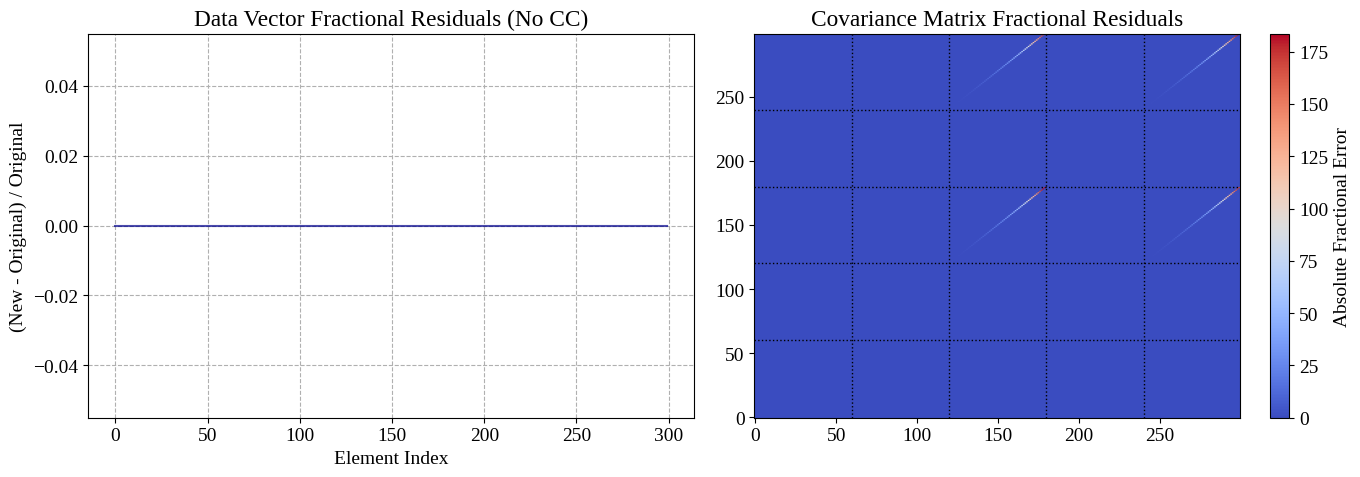

In [16]:
# compare covariance matrices and data vectors visually -- original vs new one stripped of CC

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot data vector fractional difference
ax[0].plot(vec_diff, color='darkblue', alpha=0.7)
ax[0].set_title("Data Vector Fractional Residuals (No CC)")
ax[0].set_xlabel("Element Index")
ax[0].set_ylabel("(New - Original) / Original")
ax[0].grid(True, ls='--')

# Plot covariance matrix fractional difference map
# (Using log scale to make small discrepancies visible)
cov_residual = (cov_new - cov_orig_sliced) / np.where(cov_orig_sliced == 0, 1e-30, cov_orig_sliced)
im = ax[1].imshow(np.abs(cov_residual), cmap='coolwarm', aspect='auto', origin='lower')
ax[1].set_title("Covariance Matrix Fractional Residuals")
fig.colorbar(im, ax=ax[1], label="Absolute Fractional Error")

# Add lines marking the 60-element block boundaries
for i in range(1, 5):
    ax[1].axhline(i * 60, color='black', lw=1, ls=':')
    ax[1].axvline(i * 60, color='black', lw=1, ls=':')

plt.tight_layout()
plt.show()

# The order is GG, GL, CG, LL, LC, CC

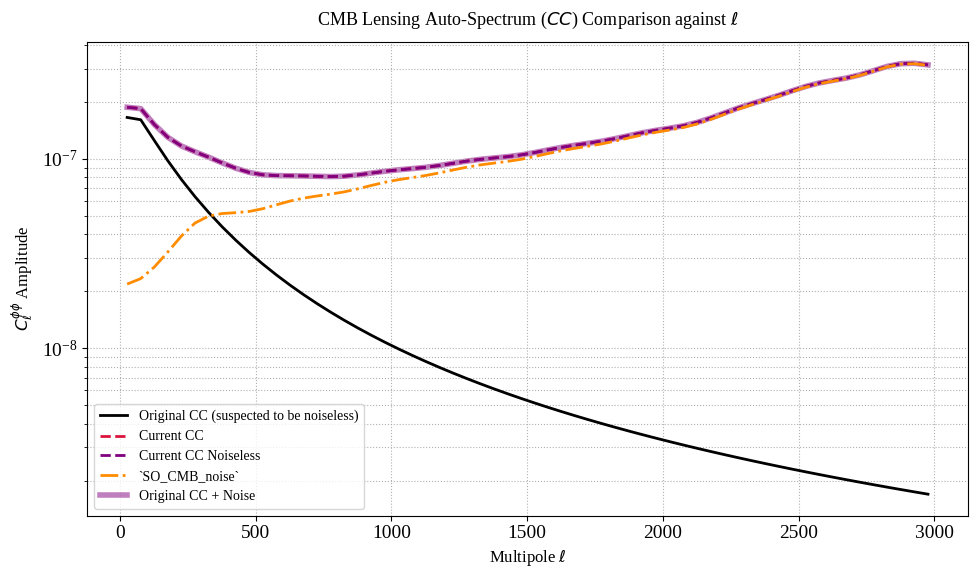

In [43]:
# compare CC blocks -- original vs new noiseless vs new with noise vs theory

# 1. Load the data vector blocks
vec_yesterday = np.load('cobaya_data/original_single_bin_data_vector.npy')
vec_today     = np.load('cobaya_data/original_single_bin_data_vector_full.npy')
vec_today_noiseless = np.load('cobaya_data/original_single_bin_data_vector_CMBnoiseless.npy')

block_size = 60
start_idx = 5 * block_size
end_idx = 6 * block_size

cc_yesterday = vec_yesterday[start_idx:end_idx]
cc_today     = vec_today[start_idx:end_idx]
cc_today_noiseless     = vec_today_noiseless[start_idx:end_idx]

# 2. Bin your SO_CMB_noise down from 3000 values to 60 bins (binsize = 50)
binsize = 50
SO_CMB_noise_binned = np.mean(SO_CMB_noise[:3000].reshape(-1, binsize), axis=1)

# 3. Create the matching binned ell midpoints for the x-axis
ell_bins = np.mean(np.arange(2, 3002)[:3000].reshape(-1, binsize), axis=1)

# 4. Sum yesterday's clean theory with the newly binned noise
cc_yesterday_with_noise = cc_yesterday + SO_CMB_noise_binned

# 5. Plot everything against the ells
plt.figure(figsize=(10, 6))

plt.plot(ell_bins, cc_yesterday, label="Original CC (suspected to be noiseless)", color='black', lw=2)
plt.plot(ell_bins, cc_today, label="Current CC", color='crimson', ls='--', lw=2)
plt.plot(ell_bins, cc_today_noiseless, label="Current CC Noiseless", color='purple', ls='--', lw=2)
plt.plot(ell_bins, SO_CMB_noise_binned, label="`SO_CMB_noise`", color='darkorange', ls='-.', lw=2)

# This line checks if adding them perfectly reproduces today's data vector line
plt.plot(ell_bins, cc_yesterday_with_noise, label="Original CC + Noise", 
         color='purple', alpha=0.5, lw=4, zorder=1)

plt.yscale('log')
plt.xlabel(r"Multipole $\ell$", fontsize=12)
plt.ylabel(r"$C_\ell^{\phi\phi}$ Amplitude", fontsize=12)
plt.title(r"CMB Lensing Auto-Spectrum ($CC$) Comparison against $\ell$", fontsize=13, pad=12)
plt.legend(fontsize=10, loc='lower left')
plt.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

In [ ]:
# Running Cobaya (CLEAN)

In [ ]:
# Cobaya from Jupyter (A_s)

In [ ]:
# bin1 one param -- omega_m
# have yaml file call these data and niose and covariances files
# then run cobaya!
# single bin single param (omega_m)
t0 = time.time()
yaml_filename = 'yaml/bin1_omega_m_likelihood_sigma8_version.yaml'
print(f"Running Cobaya sampler from YAML file: {yaml_filename}")
updated_info_from_yaml, sampler_from_yaml = cobaya_run(yaml_filename)
print("Cobaya run from YAML completed.")
tf = time.time()
time = tf - t0
print(f"Run time: {time:.4f}")

In [ ]:
# plot distribution

# distribution
samples = loadMCSamples("chains/cobaya_so_x_desi_forecast_bin1_omega_m.1.txt")

g = plots.get_subplot_plotter()
g.plot_1d(samples, 'Omega_m')
ax = plt.gca()
#ax.axvline(x=0.315, color='blue', linestyle='--', linewidth=1)

In [ ]:
# trace

#chain = np.loadtxt("chains/cobaya_so_x_desi_forecast_bin1_omega_m.1.txt")

omega_m = chain[:, 2]  # adjust index if Omega_m isn't first column

burn = int(0.2 * len(omega_m))
plt.plot(omega_m[burn:], alpha=0.3, linewidth=0.75)
plt.xlabel("Step")
plt.ylabel("Omega_m")
plt.show()
plt.show()

In [ ]:
# load emulator chains (prefix only)

chain_output_path = 'chains/cobaya_so_x_desi_emulated_forecast_bin1_omega_m'
samples = loadMCSamples(chain_output_path)

# find available parameters
param_infos = samples.getParamNames().names
param_names = [p.name for p in param_infos]

print("All parameters in chain:")
print(param_names)

# cosmology parameters
cosmo_params = ['Omega_m']

# keep only ones that actually exist in the chain
cosmo_params = [p for p in cosmo_params if p in param_names]

# make triangle plot
g = plots.get_subplot_plotter(width_inch=10)
g.triangle_plot(samples, params=cosmo_params, filled=True, linewidth=1, color='black')

plt.suptitle("Cosmology parameter constraints", fontsize=14)
plt.show()

In [ ]:
# Cobaya in NERSC Configured Job
# 1 node, 4 tasks per node, 64 CPUs per task

In [ ]:
# trace

chain1 = np.loadtxt("gathered_chains/cosmo_run_1.txt")
omega_m1 = chain[:, 2]  # adjust index if Omega_m isn't first column
burn1 = int(0.2 * len(omega_m1))

chain2 = np.loadtxt("gathered_chains/cosmo_run_2.txt")
omega_m2 = chain[:, 2]  # adjust index if Omega_m isn't first column
burn2 = int(0.2 * len(omega_m2))

plt.plot(omega_m1[burn1:], alpha=0.3, linewidth=0.75)
plt.plot(omega_m2[burn2:], alpha=0.3, linewidth=0.75)
plt.xlabel("Step")
plt.ylabel("Omega_m")
plt.show()
plt.show()

In [ ]:
## Original everything, smaller proposal step

print("Only three chains were saved, not sure what happened there.")

# 1. Use the exact path that worked for your trace plot
chain_dir = os.path.expanduser('~/DESIxSO/chains/original_likelihood_new_functions')
chain_path = os.path.join(chain_dir, 'chain_1.txt') # Adjust if using a different chain number

if os.path.exists(chain_path):
    # 2. Load the raw data safely
    chain_data = np.loadtxt(chain_path)
    
    # Extract weights, log-posterior, and Omega_m (Column index 2)
    weights = chain_data[:, 0]
    minuslogpost = chain_data[:, 1]
    omega_m_samples = chain_data[:, 2]
    
    # Apply a 20% burn-in manually to remove early unstable steps
    burn = int(0.2 * len(omega_m_samples))
    
    # 3. Create an in-memory GetDist MCSamples object
    samples = MCSamples(
        samples=omega_m_samples[burn:],
        weights=weights[burn:],
        loglikes=minuslogpost[burn:],
        names=['Omega_m'],
        labels=[r'\Omega_m'],
        settings={'ignore_rows': 0.0} # 0.0 because we already manually removed burn-in
    )
    
    # 4. Plot the 1D marginalized probability distribution
    g = plots.get_subplot_plotter(width_inch=6)
    g.plot_1d(samples, 'Omega_m', LineWidth=2, color='darkblue')
    
    plt.title(r'Marginalized $\Omega_m$ Distribution')
    plt.ylabel('Probability Density')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print(f"Error: Could not find file at {chain_path}")

# 1. Setup paths to your saved chains
chain_dir = os.path.expanduser('~/DESIxSO/chains/original_likelihood_new_functions')

plt.figure(figsize=(12, 5))

# 2. Loop through and plot each of the 4 chains
for i in range(1, 5):
    chain_path = os.path.join(chain_dir, f'chain_{i}.txt')
    
    if os.path.exists(chain_path):
        # Load the raw chain matrix
        # Column 0: weight, Column 1: -log(Post), Column 2: Omega_m
        chain_data = np.loadtxt(chain_path)
        omega_m = chain_data[:, 2]
        
        # Plot the steps
        plt.plot(omega_m, alpha=0.6, linewidth=0.8, label=f'Chain {i}')


plt.xlabel('Step Number')
plt.ylabel(r'$\Omega_m$')
plt.title(r'$\Omega_m$ MCMC Trace Plot (All 4 Parallel Chains)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.savefig('omega_m_traces.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# testing post fix

In [10]:
# calculate and save fiducial data vector and covariance matrix for single bin sigma8 with noise

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    sigma8=0.8,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 3000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data_old(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/single_bin_data_vector_sigma8_version.npy'
covariance_filename = 'cobaya_data/single_bin_covariance_matrix_sigma8_version.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

Calculating fiducial data vector and covariance matrix for single bin...
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
Fiducial data vector saved to: cobaya_data/single_bin_data_vector_sigma8_version.npy
Covariance matrix saved to: cobaya_data/single_bin_covariance_matrix_sigma8_version.npy


In [ ]:
# bin1 one param -- omega_m
# have yaml file call these data and niose and covariances files
# then run cobaya!
# single bin single param (omega_m)
t0 = time.time()
yaml_filename = 'yaml/bin1_omega_m_likelihood_sigma8_version.yaml'
print(f"Running Cobaya sampler from YAML file: {yaml_filename}")
updated_info_from_yaml, sampler_from_yaml = cobaya_run(yaml_filename)
print("Cobaya run from YAML completed.")
tf = time.time()
time = tf - t0
print(f"Run time: {time:.4f}")

Running Cobaya sampler from YAML file: yaml/bin1_omega_m_likelihood_sigma8_version.yaml
[output] Output to be read-from/written-into folder 'chains', with prefix 'cobaya_so_x_desi_forecast_bin1_omega_m_sigma8_version_w_noise'
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/single_bin_data_vector_sigma8_version.npy
  Loading covariance matrix from: cobaya_data/single_bin_covariance_matrix_sigma8_version.npy
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
SO_x_DESI_Likelihood initialized successfully.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: Omega_m:0.315
[model] Measuring speeds... (this m